# RSSI Data Analysis — Indoor Positioning

**Ziel:** Überblick über die BLE-RSSI-Daten gewinnen, Positionswahrscheinlichkeiten schätzen und Fehlerrate ermitteln.

**Methode:** Log-Distance Path Loss Model → Distanzschätzung → Multilateration (Least Squares)

**Datenquelle:** `emi_nav.db` — Tabellen `runs`, `ble_rssi`, `beacon_positions`, `door_positions`, `groundtruth`

**Referenz:** PositionEstimation.pdf (Prof. Dr. Gerald Pirkl, OTH Amberg-Weiden)

## 0 — Imports & Config

In [459]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

DB_PATH = '../data/emi_nav.db'
RSSI_0           = -70.0  # dBm bei d=1m
PATH_LOSS_EXP    =   2.0  # Innenraum-Exponent
FLOOR_HEIGHT_M = 1.5  # dB Verlust pro Stockwerk
USE_OTHER_FLOOR = True  # True = andere Etagen mit Penalty, False = ignorieren
WINDOW_MS = 1000
PIXEL_TO_METER = 0.2
RUN_IDS = ["R1", "R2", "R3"]

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print('Config geladen ✓')

Config geladen ✓


## 1 — Daten laden

In [460]:
conn = sqlite3.connect(DB_PATH)

runs_df   = pd.read_sql('SELECT * FROM runs', conn)
rssi_df   = pd.read_sql('SELECT * FROM ble_rssi', conn)

# Beacon-Positionen aus DB
beacon_pos_df = pd.read_sql('SELECT * FROM beacon_positions', conn)
BEACON_POSITIONS = {
    row.beacon_name: (row.x_m, row.y_m, row.floor)
    for row in beacon_pos_df.itertuples()
}

# Door-Positionen + Groundtruth per JOIN aus DB
gt_df = pd.read_sql("""
    SELECT g.run_id, g.tuer_id, g.timestamp_ms,
           d.x_m, d.y_m, d.floor
    FROM groundtruth g
    JOIN door_positions d ON g.tuer_id = d.tuer_id
    WHERE d.x_m IS NOT NULL AND d.y_m IS NOT NULL
""", conn)

conn.close()

# Outlier + fremde Beacons raus
rssi_df = rssi_df[rssi_df['beacon_name'].str.startswith('arrive_emi')].copy()
rssi_df = rssi_df[rssi_df['rssi'] <= 0].copy()

print(f'Runs: {len(runs_df)}')
print(f'RSSI-Messungen (gefiltert): {len(rssi_df)}')
print(f'Beacon-Positionen geladen: {len(BEACON_POSITIONS)}')
print(BEACON_POSITIONS)
print(f'Groundtruth-Punkte (mit Koordinaten): {len(gt_df)}')
print('\nBeacons:', list(BEACON_POSITIONS.keys()))
print('\nGroundtruth:')
print(gt_df)

Runs: 3
RSSI-Messungen (gefiltert): 3682
Beacon-Positionen geladen: 6
{'arrive_emi1': (74.0, 9.4, 1), 'arrive_emi2': (89.0, 8.0, 1), 'arrive_emi3': (117.60000000000001, 4.0, 1), 'arrive_emi4': (118.0, 4.0, 0), 'arrive_emi8': (74.0, 10.0, 0), 'arrive_emi10': (102.0, 8.0, 0)}
Groundtruth-Punkte (mit Koordinaten): 20

Beacons: ['arrive_emi1', 'arrive_emi2', 'arrive_emi3', 'arrive_emi4', 'arrive_emi8', 'arrive_emi10']

Groundtruth:
   run_id tuer_id   timestamp_ms    x_m   y_m  floor
0      R1     H01  1781612164000  120.0  12.0      0
1      R1     H02  1781612171000  117.4   6.2      0
2      R1    T022  1781612192000   95.0   4.4      0
3      R1     H03  1781612206000   79.2   6.0      0
4      R2     H03  1781614938000   79.2   6.0      0
5      R2     H13  1781614972000   79.2   6.0      1
6      R2     H12  1781614998000  117.4   6.2      1
7      R2     H11  1781615013000  120.0  12.0      1
8      R2     H01  1781615036000  120.0  12.0      0
9      R2     H02  1781615043000  117.

## 2 — Explorative Datenanalyse (EDA)

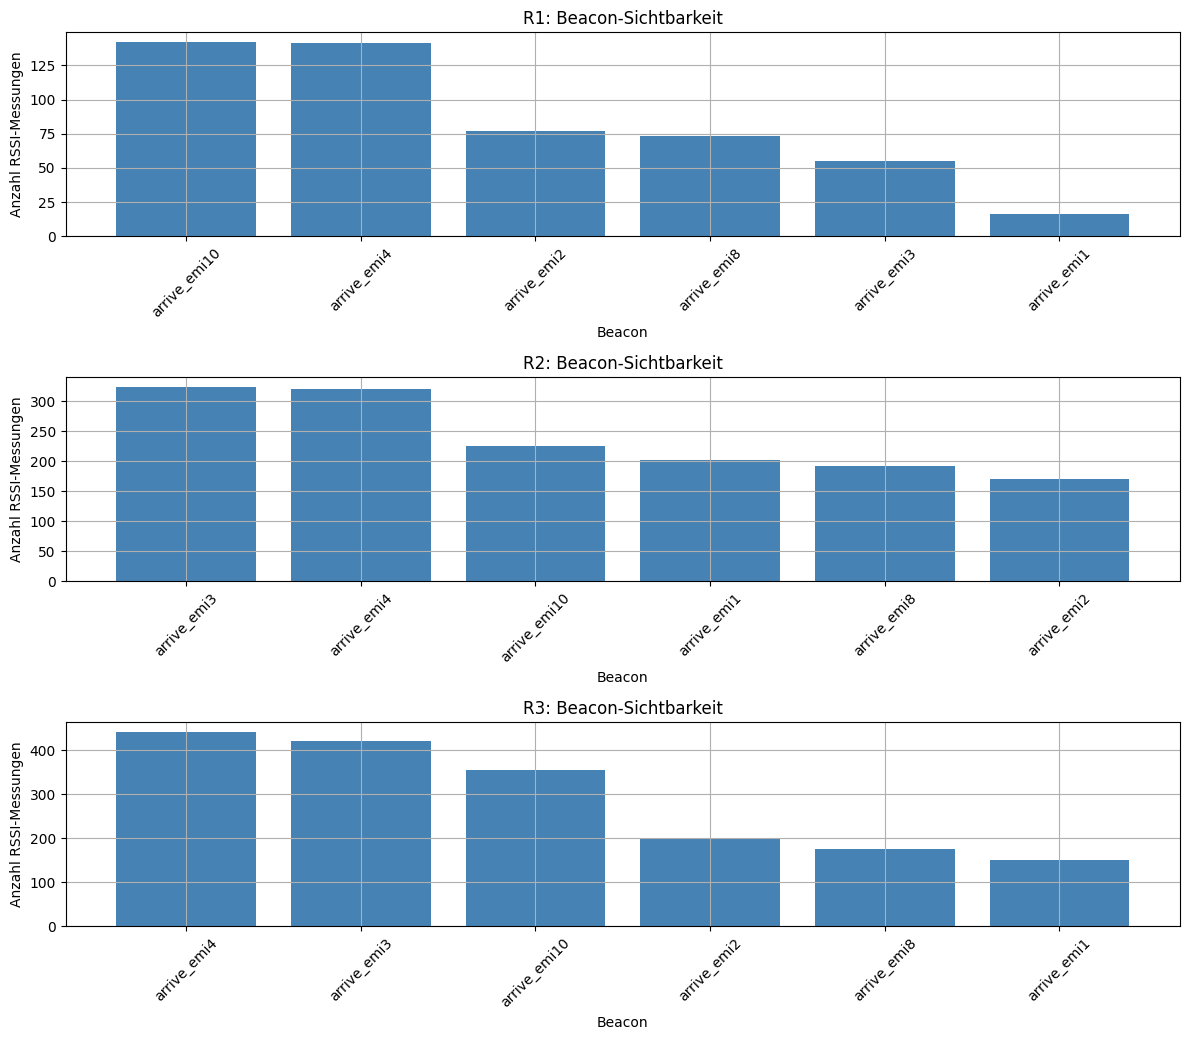

In [461]:
visibility = (
    rssi_df.groupby(["run_id", "beacon_name"])
    .size()
    .reset_index(name="n_measurements")
)

fig, axes = plt.subplots(
    len(RUN_IDS),
    1,
    figsize=(12, 3.5 * len(RUN_IDS)),
    sharex=False,
)

for ax, run_id in zip(axes, RUN_IDS):
    run_visibility = (
        visibility[visibility["run_id"] == run_id]
        .sort_values("n_measurements", ascending=False)
    )

    ax.bar(
        run_visibility["beacon_name"],
        run_visibility["n_measurements"],
        color="steelblue",
    )
    ax.set_title(f"{run_id}: Beacon-Sichtbarkeit")
    ax.set_xlabel("Beacon")
    ax.set_ylabel("Anzahl RSSI-Messungen")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

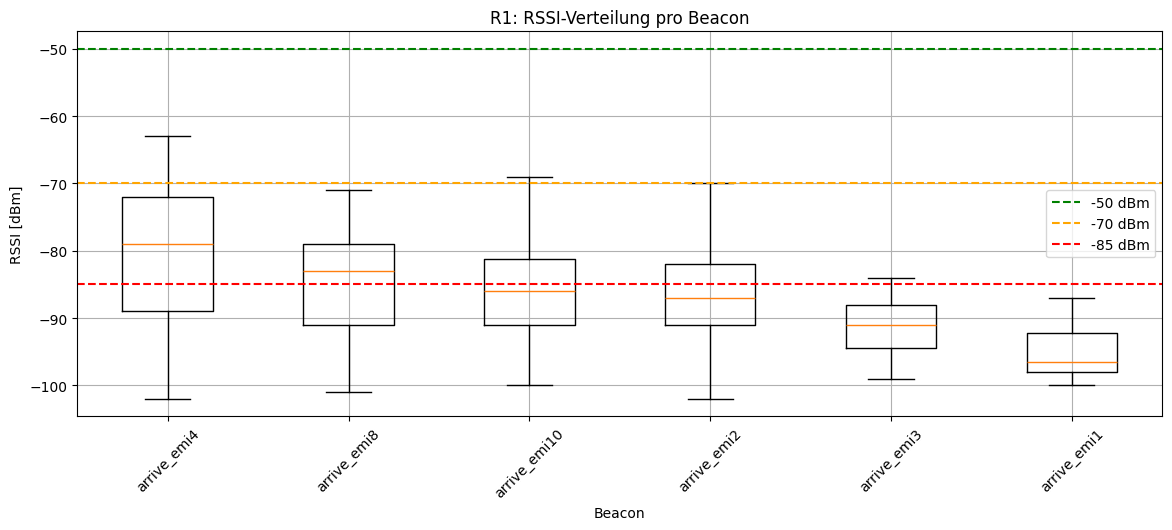

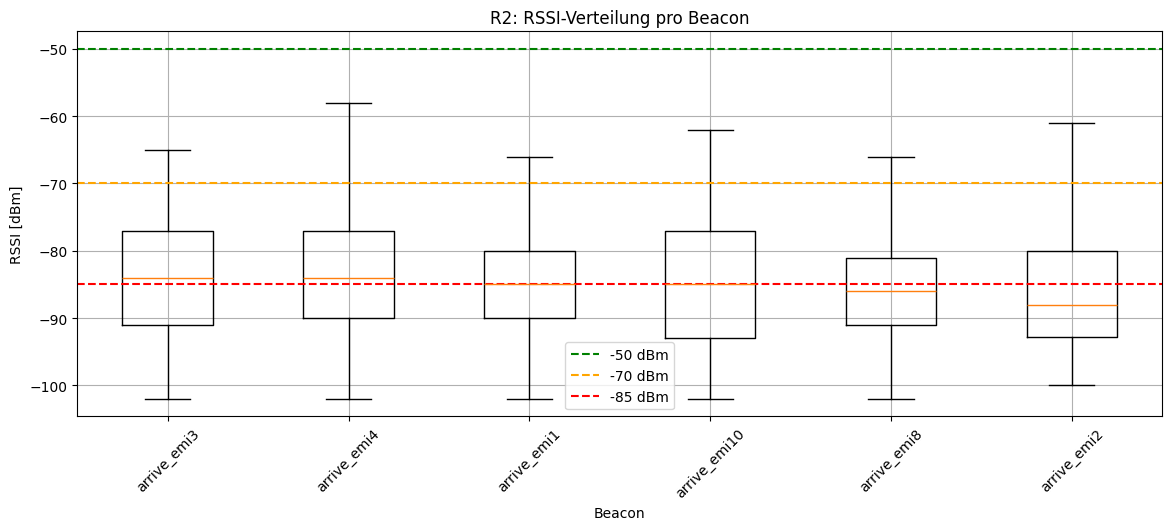

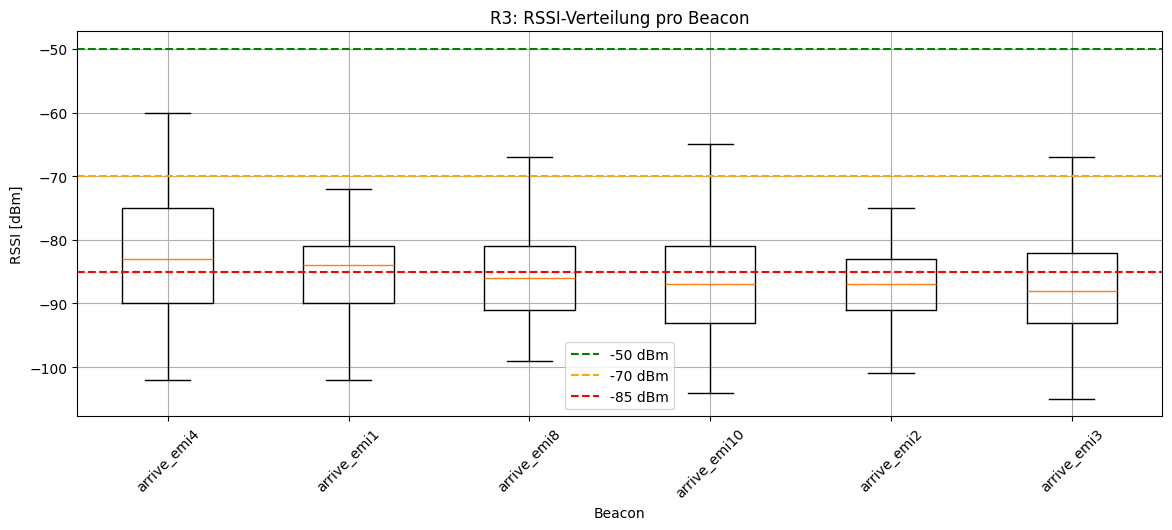

In [462]:
for run_id in RUN_IDS:
    run_ble = rssi_df[rssi_df["run_id"] == run_id]

    beacon_order = (
        run_ble.groupby("beacon_name")["rssi"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    data = [
        run_ble.loc[run_ble["beacon_name"] == beacon_id, "rssi"].dropna()
        for beacon_id in beacon_order
    ]

    plt.figure(figsize=(14, 5))
    plt.boxplot(data, tick_labels=beacon_order, showfliers=False)

    plt.axhline(-50, color="green", linestyle="--", label="-50 dBm")
    plt.axhline(-70, color="orange", linestyle="--", label="-70 dBm")
    plt.axhline(-85, color="red", linestyle="--", label="-85 dBm")

    plt.title(f"{run_id}: RSSI-Verteilung pro Beacon")
    plt.xlabel("Beacon")
    plt.ylabel("RSSI [dBm]")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

## 3 — Stockwerk-Klassifikation

In [463]:
eg_beacons = [b for b, (_, _, f) in BEACON_POSITIONS.items() if f == 0]
og_beacons = [b for b, (_, _, f) in BEACON_POSITIONS.items() if f == 1]
print(f'EG-Beacons ({len(eg_beacons)}): {eg_beacons}')
print(f'OG-Beacons ({len(og_beacons)}): {og_beacons}')

def estimate_floor(rssi_window: pd.DataFrame) -> int:
    """Heuristik: Stärkere mittlere RSSI = wahrscheinlich selbes Stockwerk."""
    rssi_eg = rssi_window[rssi_window['beacon_name'].isin(eg_beacons)]['rssi'].mean()
    rssi_og = rssi_window[rssi_window['beacon_name'].isin(og_beacons)]['rssi'].mean()

    if pd.isna(rssi_eg) and pd.isna(rssi_og):
        return -1  # keine Beacons sichtbar

    # NaN als -inf behandeln → das andere Stockwerk gewinnt automatisch
    rssi_eg = rssi_eg if not pd.isna(rssi_eg) else float("-inf")
    rssi_og = rssi_og if not pd.isna(rssi_og) else float("-inf")

    return 0 if rssi_eg >= rssi_og else 1

EG-Beacons (3): ['arrive_emi4', 'arrive_emi8', 'arrive_emi10']
OG-Beacons (3): ['arrive_emi1', 'arrive_emi2', 'arrive_emi3']


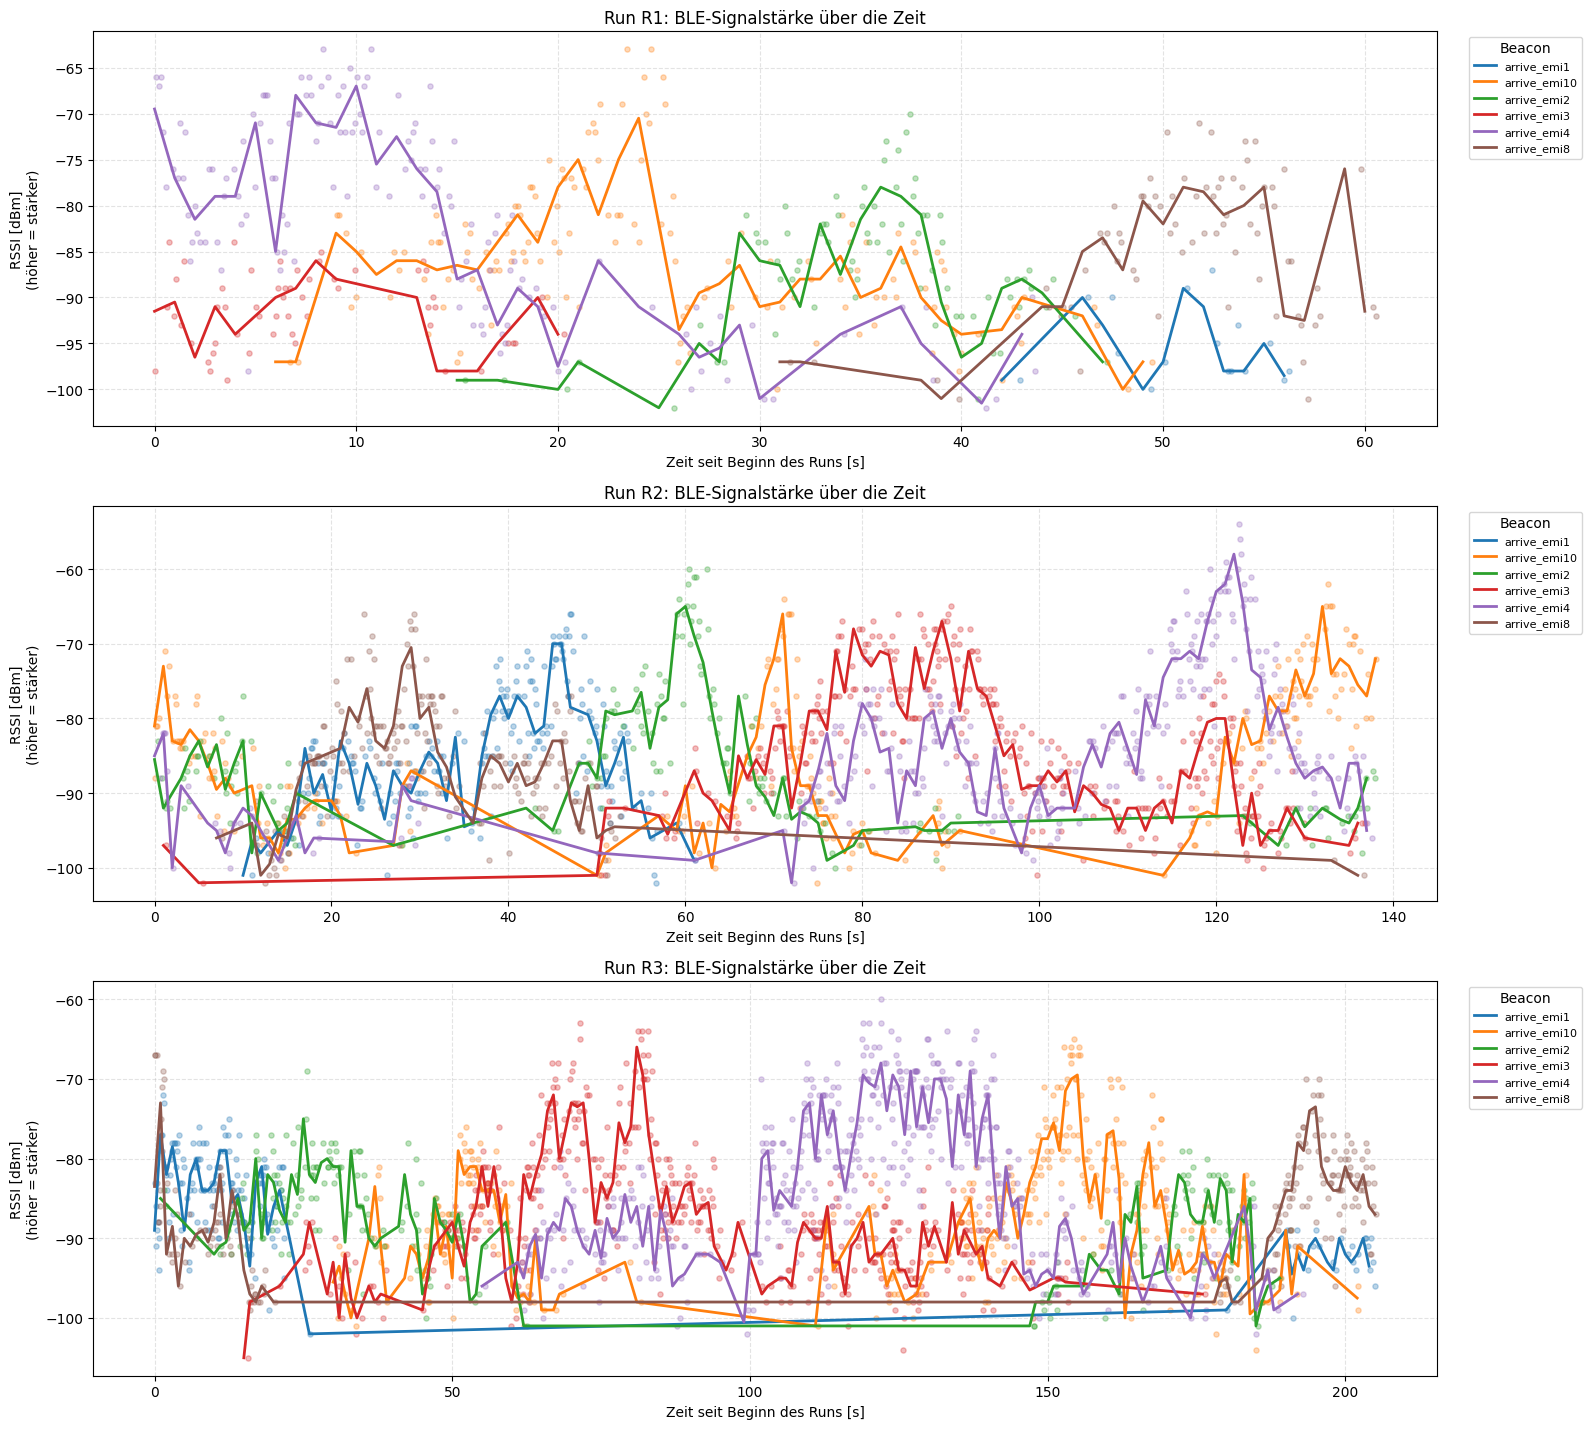

In [464]:
# Nur Beacons verwenden, für die es auch hinterlegte Koordinaten gibt
plot_data = rssi_df.loc[
    rssi_df["beacon_name"].isin(BEACON_POSITIONS.keys()),
    ["run_id", "timestamp_ms", "beacon_name", "rssi"]
].copy()

# Zeit relativ zum Beginn jedes Runs berechnen
plot_data["time_s"] = (
    plot_data["timestamp_ms"]
    - plot_data.groupby("run_id")["timestamp_ms"].transform("min")
) / WINDOW_MS

plot_data = plot_data.sort_values(["run_id", "timestamp_ms"])

run_ids = sorted(plot_data["run_id"].unique())
n_runs = len(run_ids)

fig, axes = plt.subplots(
    n_runs,
    1,
    figsize=(16, 4.8 * n_runs),
    sharex=False,
    squeeze=False
)

for ax, run_id in zip(axes.ravel(), run_ids):
    run_data = plot_data.loc[plot_data["run_id"].eq(run_id)]

    for beacon_name, group in run_data.groupby("beacon_name", sort=True):
        # Einzelmessungen: zeigen das tatsächliche RSSI-Rauschen
        ax.scatter(
            group["time_s"],
            group["rssi"],
            s=14,
            alpha=0.30
        )

        # Ein Median pro Sekunde: zeigt den verständlichen Signaltrend
        smooth = (
            group.assign(time_bin=group["time_s"].astype(int))
            .groupby("time_bin", as_index=False)["rssi"]
            .median()
        )

        ax.plot(
            smooth["time_bin"],
            smooth["rssi"],
            linewidth=2,
            label=beacon_name
        )

    ax.set_title(f"Run {run_id}: BLE-Signalstärke über die Zeit")
    ax.set_xlabel("Zeit seit Beginn des Runs [s]")
    ax.set_ylabel("RSSI [dBm]\n(höher = stärker)")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(
        title="Beacon",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

fig.tight_layout()
plt.show()

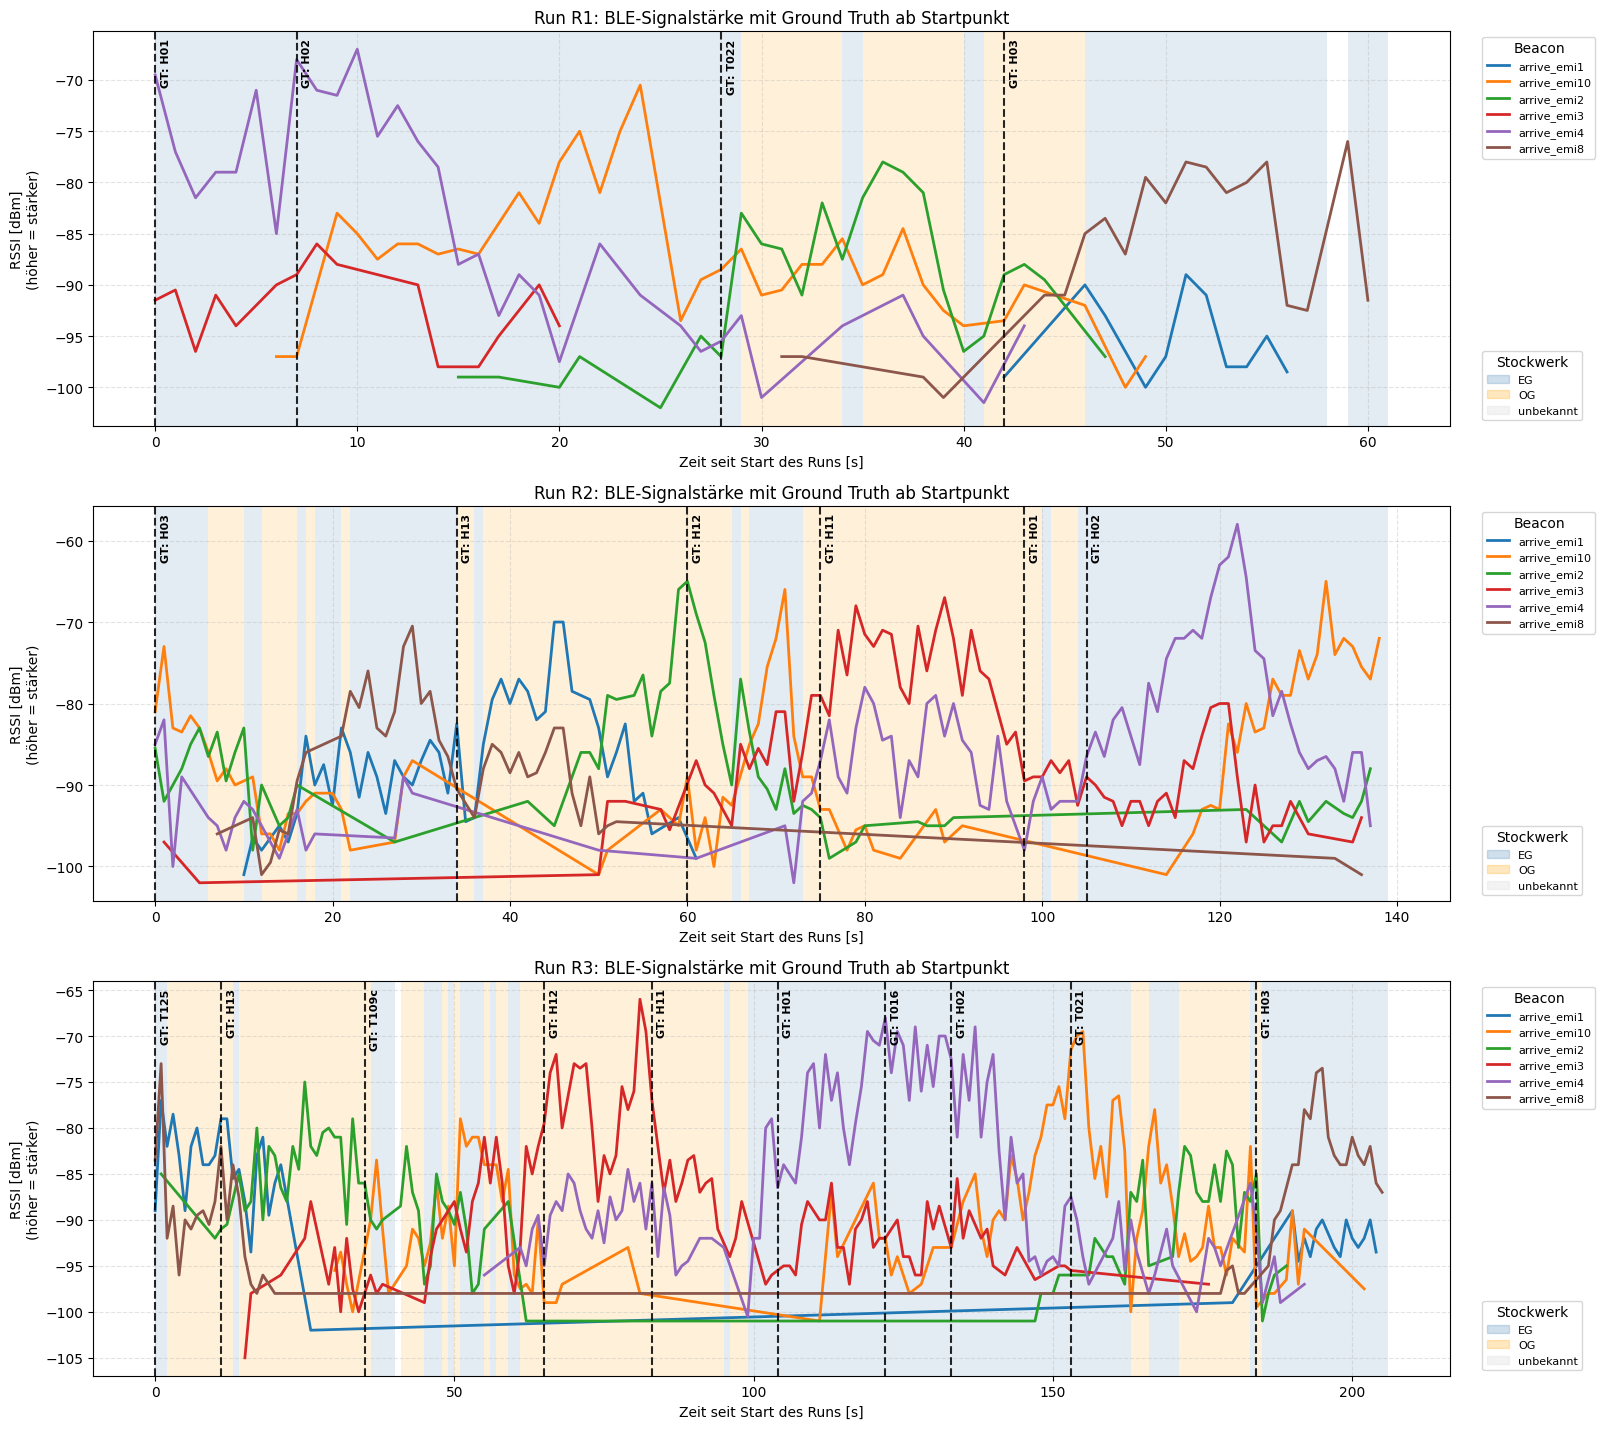

In [465]:
# ------------------------------------------------------------
# 1. BLE-Daten vorbereiten
# ------------------------------------------------------------
plot_data = rssi_df.loc[
    rssi_df["beacon_name"].isin(BEACON_POSITIONS.keys()),
    ["run_id", "timestamp_ms", "beacon_name", "rssi"]
].copy()

plot_data["timestamp_ms"] = pd.to_numeric(
    plot_data["timestamp_ms"], errors="coerce"
)
plot_data["rssi"] = pd.to_numeric(
    plot_data["rssi"], errors="coerce"
)

plot_data = plot_data.dropna(
    subset=["run_id", "timestamp_ms", "beacon_name", "rssi"]
)

plot_data = plot_data.sort_values(["run_id", "timestamp_ms"])

plot_data["time_s"] = (
    plot_data["timestamp_ms"]
    - plot_data.groupby("run_id")["timestamp_ms"].transform("min")
) / WINDOW_MS


# ------------------------------------------------------------
# 2. Ground Truth vorbereiten
# ------------------------------------------------------------
groundtruth_plot = gt_df.loc[
    gt_df["run_id"].isin(plot_data["run_id"].unique()),
    ["run_id", "tuer_id", "timestamp_ms"]
].copy()

groundtruth_plot["timestamp_ms"] = pd.to_numeric(
    groundtruth_plot["timestamp_ms"], errors="coerce"
)

groundtruth_plot = groundtruth_plot.dropna(
    subset=["run_id", "tuer_id", "timestamp_ms"]
).sort_values(["run_id", "timestamp_ms"])

groundtruth_plot["time_s"] = (
    groundtruth_plot["timestamp_ms"]
    - groundtruth_plot.groupby("run_id")["timestamp_ms"].transform("min")
) / WINDOW_MS


# ------------------------------------------------------------
# 3. Stockwerk-Farben & Legende
# ------------------------------------------------------------
floor_colors  = {0: "steelblue", 1: "orange", -1: "lightgray"}
floor_labels  = {0: "EG",        1: "OG",      -1: "unbekannt"}
floor_patches = [
    mpatches.Patch(color=floor_colors[f], alpha=0.25, label=floor_labels[f])
    for f in [0, 1, -1]
]


# ------------------------------------------------------------
# 4. Timeline je Run
# ------------------------------------------------------------
run_ids = sorted(plot_data["run_id"].unique())
n_runs  = len(run_ids)

fig, axes = plt.subplots(
    n_runs, 1,
    figsize=(16, 4.8 * n_runs),
    sharex=False,
    squeeze=False
)

for ax, run_id in zip(axes.ravel(), run_ids):
    run_data        = plot_data.loc[plot_data["run_id"].eq(run_id)]
    run_groundtruth = groundtruth_plot.loc[groundtruth_plot["run_id"].eq(run_id)]

    # -- Stockwerk-Hintergrund ----------------------------------------
    run_rssi = rssi_df.loc[rssi_df["run_id"].eq(run_id)].copy()
    run_rssi["time_bin"] = (
        (run_rssi["timestamp_ms"] - run_rssi["timestamp_ms"].min())
        / WINDOW_MS
    ).astype(int)

    for t_bin, window in run_rssi.groupby("time_bin"):
        floor = estimate_floor(window)
        ax.axvspan(
            t_bin, t_bin + 1,
            color=floor_colors[floor],
            alpha=0.15,
            zorder=0,
            linewidth=0
        )
    # -----------------------------------------------------------------

    # RSSI-Signale
    for beacon_name, group in run_data.groupby("beacon_name", sort=True):
        smooth = (
            group.assign(time_bin=group["time_s"].astype(int))
            .groupby("time_bin", as_index=False)["rssi"]
            .median()
        )
        ax.plot(
            smooth["time_bin"],
            smooth["rssi"],
            linewidth=2,
            label=beacon_name
        )

    # Ground Truth
    for _, gt in run_groundtruth.iterrows():
        ax.axvline(
            gt["time_s"],
            color="black",
            linestyle="--",
            linewidth=1.5,
            alpha=0.85,
            zorder=10
        )
        ax.annotate(
            f"GT: {gt['tuer_id']}",
            xy=(gt["time_s"], 1),
            xycoords=("data", "axes fraction"),
            xytext=(4, -5),
            textcoords="offset points",
            rotation=90,
            va="top",
            ha="left",
            fontsize=8,
            color="black",
            fontweight="bold",
            zorder=11
        )

    ax.set_title(f"Run {run_id}: BLE-Signalstärke mit Ground Truth ab Startpunkt")
    ax.set_xlabel("Zeit seit Start des Runs [s]")
    ax.set_ylabel("RSSI [dBm]\n(höher = stärker)")
    ax.grid(True, linestyle="--", alpha=0.35)

    # Beacon-Legende + Stockwerk-Legende
    beacon_legend = ax.legend(
        title="Beacon",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )
    ax.add_artist(beacon_legend)
    ax.legend(
        handles=floor_patches,
        title="Stockwerk",
        bbox_to_anchor=(1.02, 0),
        loc="lower left",
        fontsize=8
    )

fig.tight_layout()
plt.show()

## 4 — Distanzschätzung via Log-Distance Path Loss

In [466]:
def rssi_to_distance(rssi: float, floor_delta: int = 0) -> float:
    """
    Inverse Log-Distance Path Loss mit additivem Floor-Aufschlag.
    floor_delta=0 → gleiche Etage
    floor_delta>0 → +FLOOR_HEIGHT_M pro Etage wird addiert
    """
    if floor_delta != 0 and not USE_OTHER_FLOOR:
        return np.nan

    base_dist = 10.0 ** ((RSSI_0 - rssi) / (10.0 * PATH_LOSS_EXP))

    if floor_delta == 0:
        return base_dist

    # Fester Aufschlag pro Etage – unabhängig von base_dist
    return base_dist + abs(floor_delta) * FLOOR_HEIGHT_M


# ── Anwenden ────────────────────────────────────────────────────────
rssi_df['beacon_floor'] = rssi_df['beacon_name'].map(
    lambda b: BEACON_POSITIONS.get(b, (None, None, 0))[2]
)
rssi_df['floor_delta'] = rssi_df['beacon_floor'].fillna(0).astype(int)
rssi_df['dist_est_m']  = rssi_df.apply(
    lambda r: rssi_to_distance(r['rssi'], r['floor_delta']), axis=1
)

# Andere Etagen rausfiltern (wenn USE_OTHER_FLOOR=False)
rssi_df_clean = rssi_df.dropna(subset=['dist_est_m'])

print('Distanzschätzungen (Beispiel):')
print(rssi_df_clean[['run_id','beacon_name','rssi','floor_delta','dist_est_m']].head(10).round(2))

Distanzschätzungen (Beispiel):
  run_id  beacon_name  rssi  floor_delta  dist_est_m
0     R1  arrive_emi3 -98.0            1       26.62
1     R1  arrive_emi4 -66.0            0        0.63
2     R1  arrive_emi4 -67.0            0        0.71
3     R1  arrive_emi4 -66.0            0        0.63
4     R1  arrive_emi4 -72.0            0        1.26
5     R1  arrive_emi4 -78.0            0        2.51
6     R1  arrive_emi3 -91.0            1       12.72
7     R1  arrive_emi3 -84.0            1        6.51
8     R1  arrive_emi4 -76.0            0        2.00
9     R1  arrive_emi3 -92.0            1       14.09


## 5 — Multilateration (Least Squares)

In [467]:
from scipy.optimize import minimize

# Beacon-Positionen um Z erweitern
BEACON_POSITIONS_3D = {
    name: (x, y, floor * FLOOR_HEIGHT_M)
    for name, (x, y, floor) in BEACON_POSITIONS.items()
}

def multilaterate_3d(beacon_positions_3d: list, distances: list) -> tuple:
    """
    3D Least Squares Multilateration.
    Gibt (x, y, z) zurück — z dann in Stockwerk umrechnen.
    """
    if len(beacon_positions_3d) < 4:
        # Mit 3 Beacons: z fixieren auf wahrscheinlichstes Stockwerk
        # und 2D lösen — Fallback
        return None, None, None, None

    beacons = np.array(beacon_positions_3d)  # shape (n, 3)
    dists   = np.array(distances)

    def residual(pos):
        diff = beacons - pos  # (n, 3)
        dist_est = np.sqrt((diff**2).sum(axis=1))
        return np.sum((dist_est - dists)**2)

    x0 = [beacons[:, 0].mean(), beacons[:, 1].mean(), beacons[:, 2].mean()]
    result = minimize(residual, x0=x0, method='Nelder-Mead',
                      options={'xatol': 0.1, 'fatol': 0.1, 'maxiter': 2000})

    x_est, y_est, z_est = result.x
    floor_est = 0 if z_est < FLOOR_HEIGHT_M / 2 else 1
    return x_est, y_est, z_est, floor_est

def estimate_positions_for_run_drei(run_id: str, window_ms: int = 2000) -> pd.DataFrame:
    run_data = rssi_df[rssi_df['run_id'] == run_id].sort_values('timestamp_ms')
    t_start, t_end = run_data['timestamp_ms'].min(), run_data['timestamp_ms'].max()
    results, t = [], t_start

    while t < t_end:
        window = run_data[
            (run_data['timestamp_ms'] >= t) &
            (run_data['timestamp_ms'] <  t + window_ms)
        ]
        avg = window.groupby('beacon_name').agg(
            rssi=('rssi', 'mean')
        ).reset_index()
        avg = avg[avg['beacon_name'].isin(BEACON_POSITIONS_3D)].copy()
        avg['dist'] = avg['rssi'].apply(rssi_to_distance)  # kein floor_delta mehr nötig!

        positions_3d = [BEACON_POSITIONS_3D[b] for b in avg['beacon_name']]
        x_est, y_est, z_est, floor_est = multilaterate_3d(positions_3d, avg['dist'].tolist())

        results.append({
            'run_id':       run_id,
            'timestamp_ms': t + window_ms // 2,
            'x_est':        x_est,
            'y_est':        y_est,
            'z_est':        z_est,
            'floor_est':    floor_est,
            'n_beacons':    len(avg),
        })
        t += window_ms // 2  # 50% Überlappung

    return pd.DataFrame(results).dropna(subset=['x_est', 'y_est'])

all_positions = pd.concat(
    [estimate_positions_for_run_drei(r) for r in runs_df['run_id']],
    ignore_index=True
)
print(f'Positionsschätzungen gesamt: {len(all_positions)}')
print(all_positions.head(10).round(2))

Positionsschätzungen gesamt: 94
  run_id   timestamp_ms   x_est  y_est  z_est  floor_est  n_beacons
0     R1  1781612188694  111.36  16.24  -0.05        0.0          4
1     R1  1781612189694  110.71  17.62   0.25        0.0          4
2     R1  1781612190694  110.27  11.44  -7.16        0.0          4
3     R1  1781612191694  110.14  14.11  -0.03        0.0          4
4     R1  1781612193694  111.43  15.01  -0.16        0.0          4
5     R1  1781612194694  103.95   6.25   0.75        0.0          4
6     R1  1781612204694   90.92  16.87   0.34        0.0          4
7     R1  1781612211694   98.21   3.76   0.50        0.0          4
8     R1  1781612212694   99.11  -0.30   0.77        1.0          4
9     R1  1781612215694   92.32   7.76   0.78        1.0          4


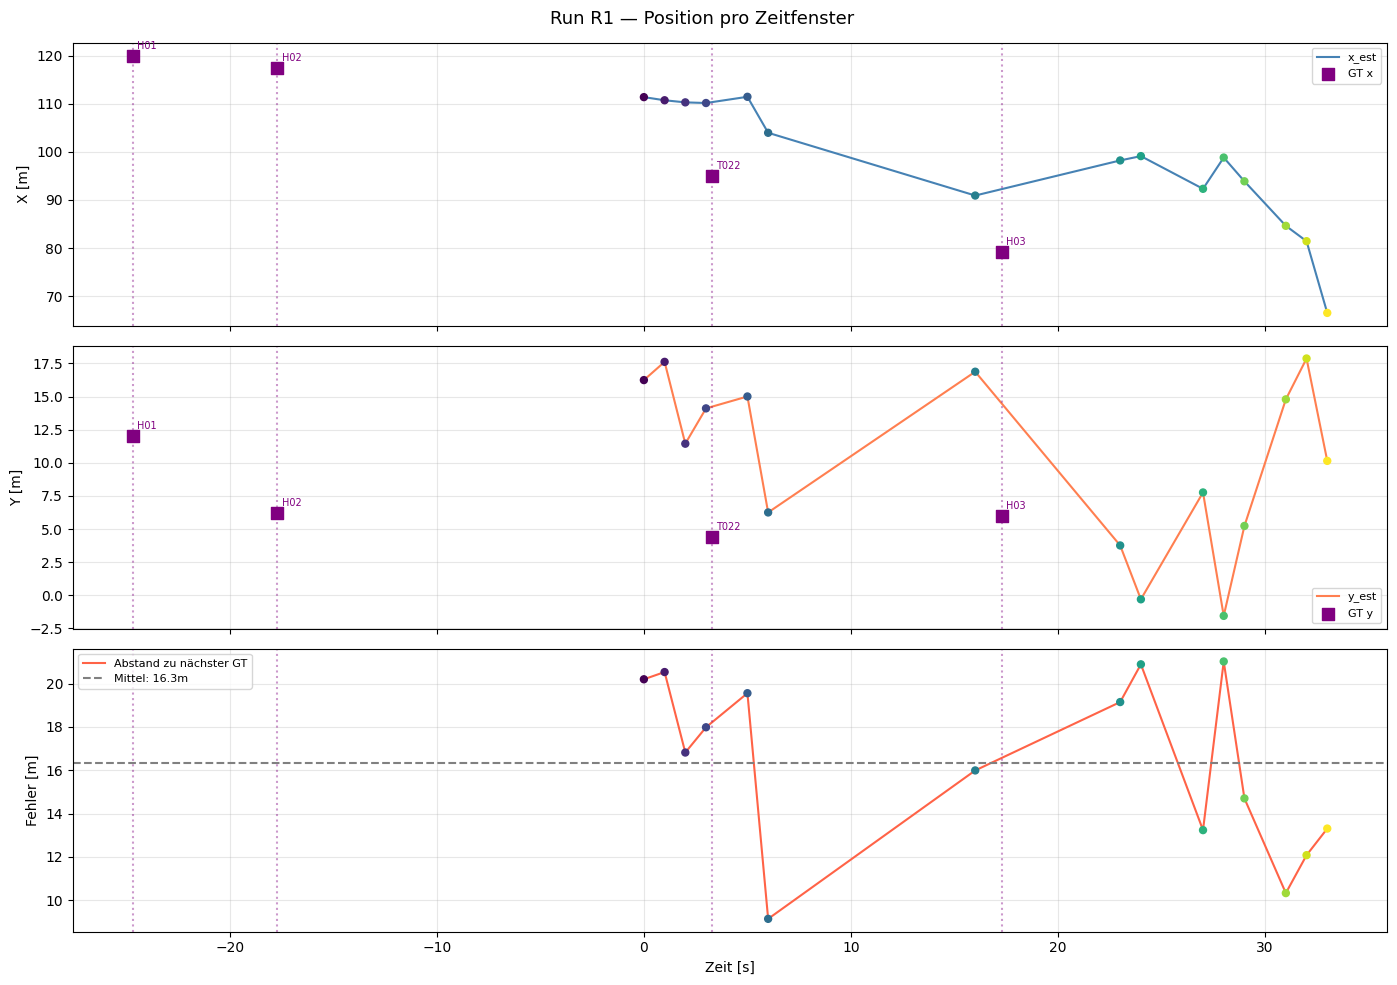

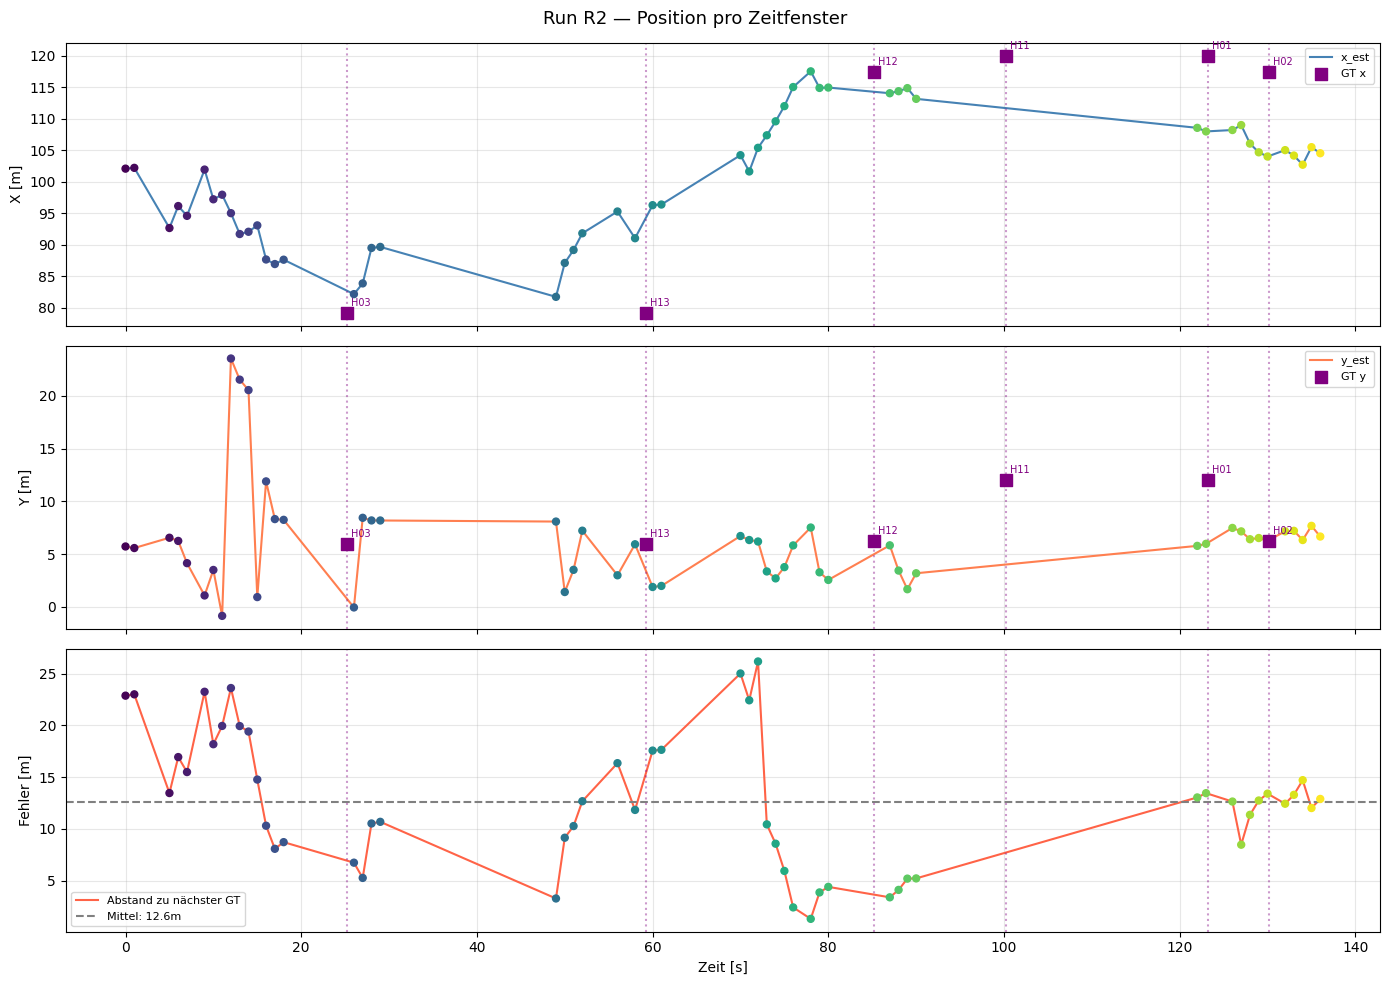

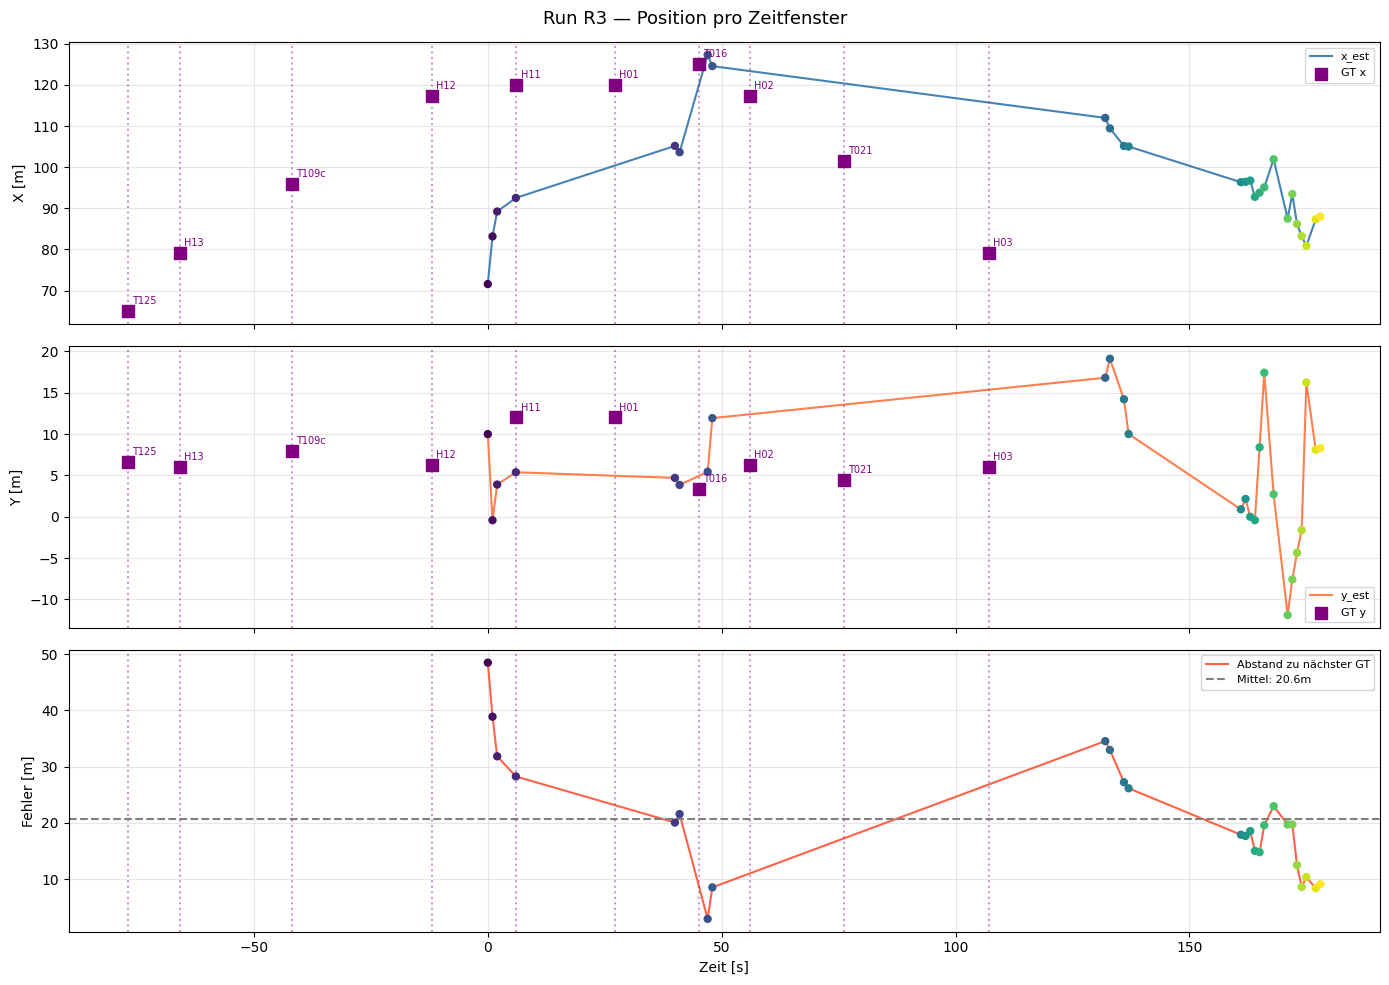

In [468]:
## 6b — Position pro Zeitfenster (Timeline)

for run in runs_list:
    df_run = all_positions[all_positions['run_id']==run].sort_values('timestamp_ms').reset_index(drop=True)
    gt_run = gt_df[gt_df['run_id']==run].sort_values('timestamp_ms')
    if len(df_run) == 0: continue

    # Zeitachse normalisieren auf Sekunden ab Start
    t0 = df_run['timestamp_ms'].iloc[0]
    df_run = df_run.copy(); df_run['t_sec'] = (df_run['timestamp_ms'] - t0) / 1000
    if len(gt_run) > 0:
        gt_run = gt_run.copy(); gt_run['t_sec'] = (gt_run['timestamp_ms'] - t0) / 1000

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Run {run} — Position pro Zeitfenster', fontsize=13)

    # X über Zeit
    axes[0].plot(df_run['t_sec'], df_run['x_est'], color='steelblue', linewidth=1.5, label='x_est')
    axes[0].scatter(df_run['t_sec'], df_run['x_est'], c=range(len(df_run)), cmap='viridis', s=25, zorder=3)
    if len(gt_run) > 0:
        axes[0].scatter(gt_run['t_sec'], gt_run['x_m'], color='purple', s=80, marker='s', zorder=4, label='GT x')
        for _, r in gt_run.iterrows():
            axes[0].axvline(r['t_sec'], color='purple', linestyle=':', alpha=0.4)
            axes[0].annotate(r['tuer_id'], (r['t_sec'], r['x_m']), textcoords='offset points', xytext=(3,5), fontsize=7, color='purple')
    axes[0].set_ylabel('X [m]'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    # Y über Zeit
    axes[1].plot(df_run['t_sec'], df_run['y_est'], color='coral', linewidth=1.5, label='y_est')
    axes[1].scatter(df_run['t_sec'], df_run['y_est'], c=range(len(df_run)), cmap='viridis', s=25, zorder=3)
    if len(gt_run) > 0:
        axes[1].scatter(gt_run['t_sec'], gt_run['y_m'], color='purple', s=80, marker='s', zorder=4, label='GT y')
        for _, r in gt_run.iterrows():
            axes[1].axvline(r['t_sec'], color='purple', linestyle=':', alpha=0.4)
            axes[1].annotate(r['tuer_id'], (r['t_sec'], r['y_m']), textcoords='offset points', xytext=(3,5), fontsize=7, color='purple')
    axes[1].set_ylabel('Y [m]'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    # Fehler zur nächsten Groundtruth
    if len(gt_run) > 0:
        errors = []
        for _, row in df_run.iterrows():
            idx = (gt_run['timestamp_ms'] - row['timestamp_ms']).abs().idxmin()
            gt_nearest = gt_run.loc[idx]
            err = np.sqrt((row['x_est']-gt_nearest['x_m'])**2 + (row['y_est']-gt_nearest['y_m'])**2)
            errors.append(err)
        axes[2].plot(df_run['t_sec'], errors, color='tomato', linewidth=1.5, label='Abstand zu nächster GT')
        axes[2].scatter(df_run['t_sec'], errors, c=range(len(df_run)), cmap='viridis', s=25, zorder=3)
        axes[2].axhline(np.mean(errors), color='gray', linestyle='--', label=f'Mittel: {np.mean(errors):.1f}m')
        for _, r in gt_run.iterrows():
            axes[2].axvline(r['t_sec'], color='purple', linestyle=':', alpha=0.4)
            axes[2].annotate(r['tuer_id'], (r['t_sec'], 0), textcoords='offset points', xytext=(3,5), fontsize=7, color='purple')
        axes[2].set_ylabel('Fehler [m]'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'Keine Groundtruth-Daten', ha='center', va='center', transform=axes[2].transAxes)

    axes[2].set_xlabel('Zeit [s]')
    plt.tight_layout()
    #plt.savefig(f'position_timeline_{run}.png', dpi=130)
    plt.show()

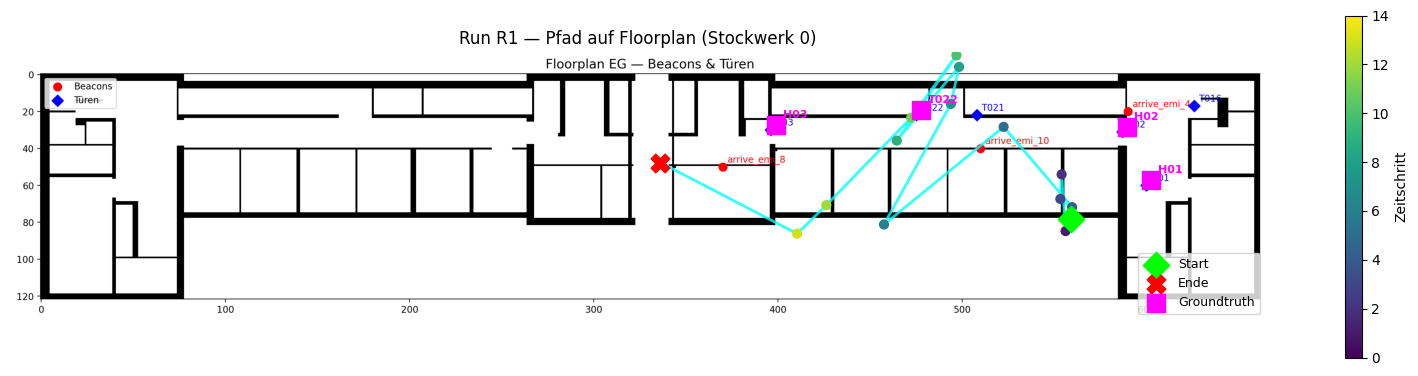

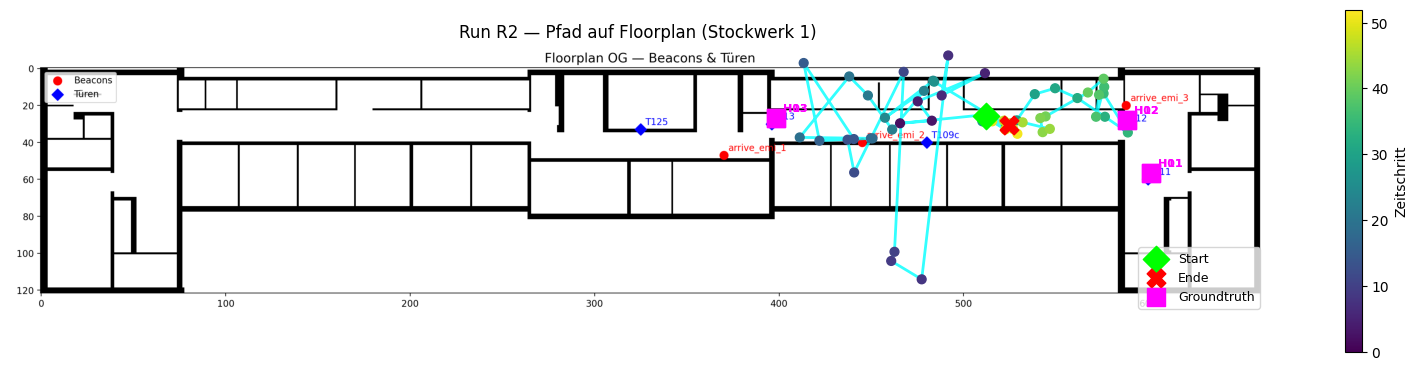

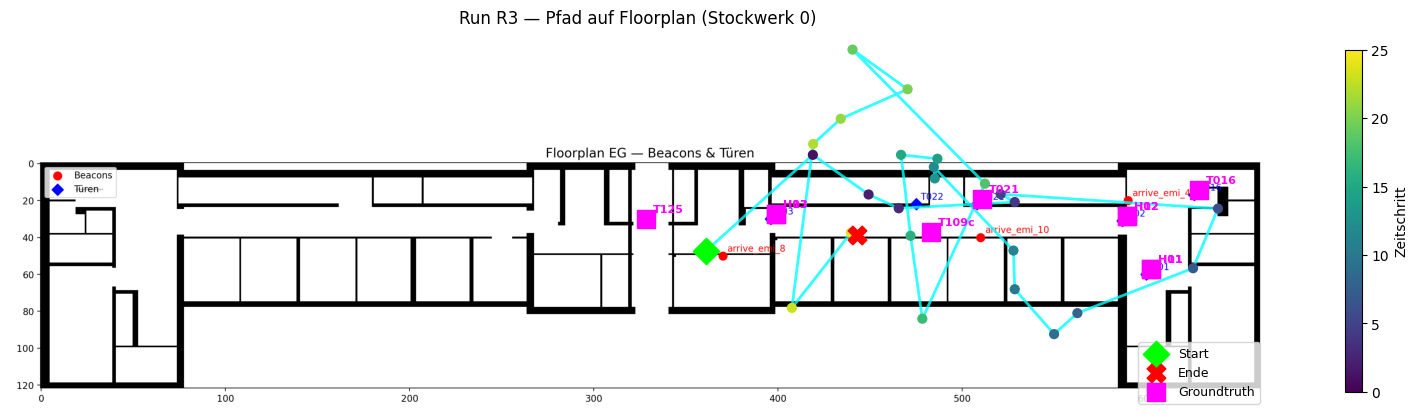

In [ ]:
FLOORPLAN = {
    0: '../data/floorplans/emi_map_eg_beacons_doors.png',
    1: '../data/floorplans/emi_map_og_beacons_doors.png',
}

# Kalibrierungsparameter (EG)
OCC_XMIN   = 30        # xs.min() aus occupancy_map
OCC_YMIN   = 13           # ys.min() aus occupancy_map
SCALE_F    = 4.009        # occ→img (RESOLUTION=0.05m)
PX_PER_M   = 28.00        # px/m in emi_map img

ORIGIN_X   = OCC_XMIN * SCALE_F   # = 417 px
ORIGIN_Y   = OCC_YMIN * SCALE_F   # = 204 px

def meter_to_pixel(x_m, y_m):
    px = int(round(ORIGIN_X + x_m * PX_PER_M))
    py = int(round(ORIGIN_Y + y_m * PX_PER_M))
    return px, py

for run in runs_list:
    df_run = all_positions[all_positions['run_id']==run].sort_values('timestamp_ms')
    gt_run = gt_df[gt_df['run_id']==run]
    if len(df_run) == 0: continue

    floor = int(df_run['floor_est'].mode()[0]) if 'floor_est' in df_run else 0
    img   = mpimg.imread(FLOORPLAN[floor])

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.imshow(img)
    ax.axis('off')

    # Pfad
    xs = [meter_to_pixel(x, y)[0] for x, y in zip(df_run['x_est'], df_run['y_est'])]
    ys = [meter_to_pixel(x, y)[1] for x, y in zip(df_run['x_est'], df_run['y_est'])]
    ax.plot(xs, ys, color='cyan', linewidth=2, alpha=0.8, zorder=2)
    sc = ax.scatter(xs, ys, c=range(len(xs)), cmap='viridis', s=40, zorder=3)
    plt.colorbar(sc, ax=ax, label='Zeitschritt', shrink=0.6)
    ax.scatter(xs[0],  ys[0],  color='lime', s=180, marker='D', zorder=5, label='Start')
    ax.scatter(xs[-1], ys[-1], color='red',  s=180, marker='X', zorder=5, label='Ende')

    #Groundtruth
    if len(gt_run) > 0:
         gxs = [meter_to_pixel(x, y)[0] for x, y in zip(gt_run['x_m'], gt_run['y_m'])]
         gys = [meter_to_pixel(x, y)[1] for x, y in zip(gt_run['x_m'], gt_run['y_m'])]
         ax.scatter(gxs, gys, color='magenta', s=150, marker='s', zorder=6, label='Groundtruth')
         for (gx, gy), (_, r) in zip(zip(gxs, gys), gt_run.iterrows()):
             ax.annotate(r['tuer_id'], (gx, gy), textcoords='offset points',
                         xytext=(5, 5), fontsize=8, color='magenta',
                         fontweight='bold')

    ax.set_title(f'Run {run} — Pfad auf Floorplan (Stockwerk {floor})', fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    #plt.savefig(f'path_on_map_{run}.png', dpi=130)
    plt.show()

## 7 — Positionswahrscheinlichkeit (KDE Heatmap)

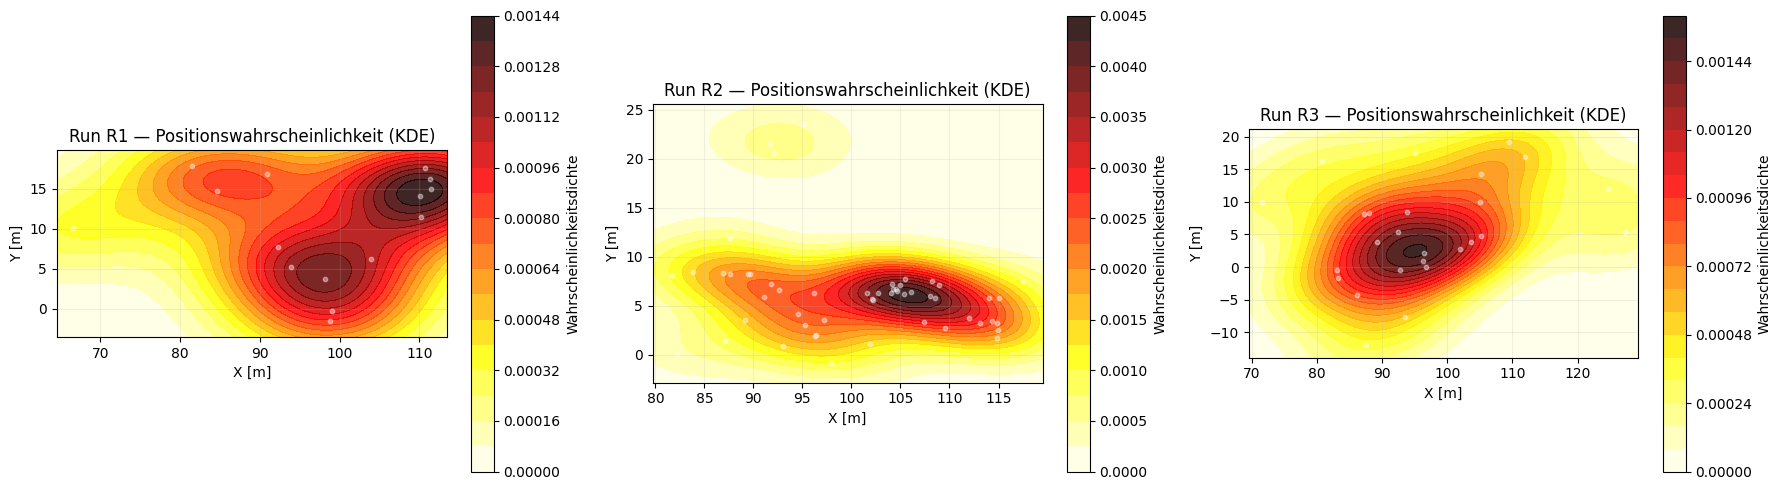

In [470]:
fig, axes = plt.subplots(1, len(runs_list), figsize=(6*len(runs_list), 5), squeeze=False)

for ax, run in zip(axes[0], runs_list):
    df_run = all_positions[all_positions['run_id'] == run].dropna()
    if len(df_run) < 5:
        ax.set_title(f'Run {run} — zu wenig Daten'); continue
    xy  = np.vstack([df_run['x_est'], df_run['y_est']])
    kde = gaussian_kde(xy)
    x_grid = np.linspace(df_run['x_est'].min()-2, df_run['x_est'].max()+2, 100)
    y_grid = np.linspace(df_run['y_est'].min()-2, df_run['y_est'].max()+2, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    im = ax.contourf(X, Y, Z, levels=20, cmap='hot_r', alpha=0.85)
    plt.colorbar(im, ax=ax, label='Wahrscheinlichkeitsdichte')
    ax.scatter(df_run['x_est'], df_run['y_est'], s=10, color='white', alpha=0.4, zorder=2)
    ax.set_title(f'Run {run} — Positionswahrscheinlichkeit (KDE)')
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

plt.tight_layout()
#plt.savefig('position_probability_kde.png', dpi=130)
plt.show()

In [493]:
import matplotlib.animation as animation

for run in runs_list:
    df_run = all_positions[all_positions['run_id'] == run].sort_values('timestamp_ms')
    gt_run = gt_df[gt_df['run_id'] == run]
    if len(df_run) == 0:
        continue

    floor = int(df_run['floor_est'].mode()[0]) if 'floor_est' in df_run else 0
    img   = mpimg.imread(FLOORPLAN[floor])
    h, w  = img.shape[:2]
    dpi   = 100

    # Zeitfenster vorbereiten
    t_min = df_run['timestamp_ms'].min()
    t_max = df_run['timestamp_ms'].max()
    windows = range(int(t_min), int(t_max), WINDOW_MS)

    fig, ax = plt.subplots(figsize=(w / dpi, h / dpi), dpi=dpi)
    ax.imshow(img, extent=[0, w, h, 0])
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.axis('off')

    # Ground Truth einmalig plotten (ändert sich nicht)
    if len(gt_run) > 0:
        gxs = [meter_to_pixel(x, y)[0] for x, y in zip(gt_run['x_m'], gt_run['y_m'])]
        gys = [meter_to_pixel(x, y)[1] for x, y in zip(gt_run['x_m'], gt_run['y_m'])]
        ax.scatter(gxs, gys, color='magenta', s=150, marker='s', zorder=6)
        for (gx, gy), (_, r) in zip(zip(gxs, gys), gt_run.iterrows()):
            ax.annotate(r['tuer_id'], (gx, gy), textcoords='offset points',
                        xytext=(5, 5), fontsize=8, color='magenta', fontweight='bold')

    # Beacon-Positionen einmalig plotten
    for name, (bx, by, bfloor) in BEACON_POSITIONS.items():
        bpx, bpy = meter_to_pixel(bx, by)
        ax.scatter([bpx], [bpy], color='yellow', s=80, marker='^', zorder=5)

    # Dynamische Elemente – werden pro Frame neu gezeichnet
    path_line,   = ax.plot([], [], color='cyan', linewidth=2, alpha=0.8, zorder=2)
    pos_dot      = ax.scatter([], [], color='red', s=180, marker='o', zorder=7)
    title        = ax.set_title('')
    circles      = []  # Beacon-Radien

    def init():
        path_line.set_data([], [])
        return [path_line, pos_dot]

    circles = []

    def update(t_start):

        # Alte Kreise entfernen
        for c in circles:
            c.remove()
        circles.clear()

        # Pfad bis zum aktuellen Zeitpunkt
        past = df_run[df_run['timestamp_ms'] <= t_start + WINDOW_SIZE * 1000]
        xs = [meter_to_pixel(x, y)[0] for x, y in zip(past['x_est'], past['y_est'])]
        ys = [meter_to_pixel(x, y)[1] for x, y in zip(past['x_est'], past['y_est'])]
        path_line.set_data(xs, ys)

        # Aktueller Punkt
        if len(xs) > 0:
            pos_dot.set_offsets([[xs[-1], ys[-1]]])

        # Beacon-Radien aus aktuellem Zeitfenster
        window_rssi = rssi_df[
            (rssi_df['run_id'] == run) &
            (rssi_df['timestamp_ms'].between(t_start, t_start + WINDOW_SIZE * 1000))
        ].copy()
        window_rssi['dist_est_m'] = window_rssi.apply(
            lambda row: rssi_to_distance(row['rssi']), axis=1
        )
        radius_per_beacon = (window_rssi
            .groupby('beacon_name')['dist_est_m']
            .median()
            .to_dict()
        )

        for name, (bx, by, bfloor) in BEACON_POSITIONS.items():
            radius_m  = radius_per_beacon.get(name, None)
            if radius_m is None or np.isnan(radius_m):
                continue
            bpx, bpy  = meter_to_pixel(bx, by)
            radius_px = radius_m / PIXEL_TO_METER

            c1 = plt.Circle((bpx, bpy), radius_px,
                             color='cyan', alpha=0.12, fill=True, zorder=3)
            c2 = plt.Circle((bpx, bpy), radius_px,
                             color='cyan', fill=False,
                             linestyle='--', linewidth=1.2, zorder=3)
            ax.add_patch(c1)
            ax.add_patch(c2)
            circles.extend([c1, c2])

        # Zeitstempel als Titel
        t_rel = (t_start - t_min) / 1000
        ax.set_title(f'Run {run} — t = {t_rel:.0f}s', fontsize=12)

        return [path_line, pos_dot] + circles

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=windows,
        init_func=init,
        interval=300,   # ms pro Frame → ~3 FPS, anpassen nach Geschmack
        blit=False      # blit=True wäre schneller, aber mit Patches schwierig
    )

    # Als GIF speichern oder direkt anzeigen
    #ani.save(f'path_animated_{run}.gif', writer='pillow', fps=3, dpi=80)
    # alternativ: plt.show()  ← funktioniert nur in interaktiven Notebooks
    plt.close()
    print(f"Run {run} gespeichert.")

Run R1 gespeichert.
Run R2 gespeichert.
Run R3 gespeichert.


## 8 — Fehleranalyse (Groundtruth aus DB)

In [472]:
def compute_errors(run_id: str, pos_df: pd.DataFrame, gt: pd.DataFrame) -> pd.DataFrame:
    """Findet zum GT-Zeitpunkt die nächste Schätzung und berechnet Euklidischen Fehler."""
    errors = []
    for _, row in gt.iterrows():
        idx = (pos_df['timestamp_ms'] - row['timestamp_ms']).abs().argsort().iloc[0]
        est = pos_df.iloc[idx]
        err = np.sqrt((est['x_est'] - row['x_m'])**2 + (est['y_est'] - row['y_m'])**2)
        errors.append({
            'run_id':  run_id,
            'tuer_id': row['tuer_id'],
            'x_gt':    row['x_m'],   'y_gt': row['y_m'],
            'x_est':   est['x_est'], 'y_est': est['y_est'],
            'error_m': err
        })
    return pd.DataFrame(errors)


error_dfs = []
for run_id in runs_df['run_id']:
    gt_run  = gt_df[gt_df['run_id'] == run_id]
    run_pos = all_positions[all_positions['run_id'] == run_id]
    if gt_run.empty:
        print(f'Run {run_id}: Keine Groundtruth-Koordinaten in DB.')
        continue
    error_dfs.append(compute_errors(run_id, run_pos, gt_run))

if error_dfs:
    all_errors = pd.concat(error_dfs, ignore_index=True)
    print('=== Fehlerstatistik (Meter) ===')
    print(all_errors.groupby('run_id')['error_m'].agg(['mean','median','std','max']).round(2))
    print(f'\nGesamtfehler (RMSE): {np.sqrt((all_errors["error_m"]**2).mean()):.2f} m')
    print('\nDetail:')
    print(all_errors.round(2))
else:
    print('Fehleranalyse: door_positions in DB befüllen.')

=== Fehlerstatistik (Meter) ===
         mean  median    std    max
run_id                             
R1      13.83   13.85   3.83  17.98
R2      10.96   12.29   5.12  17.57
R3      20.21   20.35  13.74  45.98

Gesamtfehler (RMSE): 19.29 m

Detail:
   run_id tuer_id   x_gt  y_gt   x_est  y_est  error_m
0      R1     H01  120.0  12.0  111.36  16.24     9.63
1      R1     H02  117.4   6.2  111.36  16.24    11.72
2      R1    T022   95.0   4.4  110.14  14.11    17.98
3      R1     H03   79.2   6.0   90.92  16.87    15.99
4      R2     H03   79.2   6.0   82.18  -0.05     6.75
5      R2     H13   79.2   6.0   96.28   1.88    17.57
6      R2     H12  117.4   6.2  114.02   5.83     3.40
7      R2     H11  120.0  12.0  113.13   3.18    11.18
8      R2     H01  120.0  12.0  107.97   5.98    13.46
9      R2     H02  117.4   6.2  103.99   6.26    13.41
10     R3    T125   65.0   6.6   71.57   9.99     7.40
11     R3     H13   79.2   6.0   71.57   9.99     8.61
12     R3   T109c   96.0   8.0   7

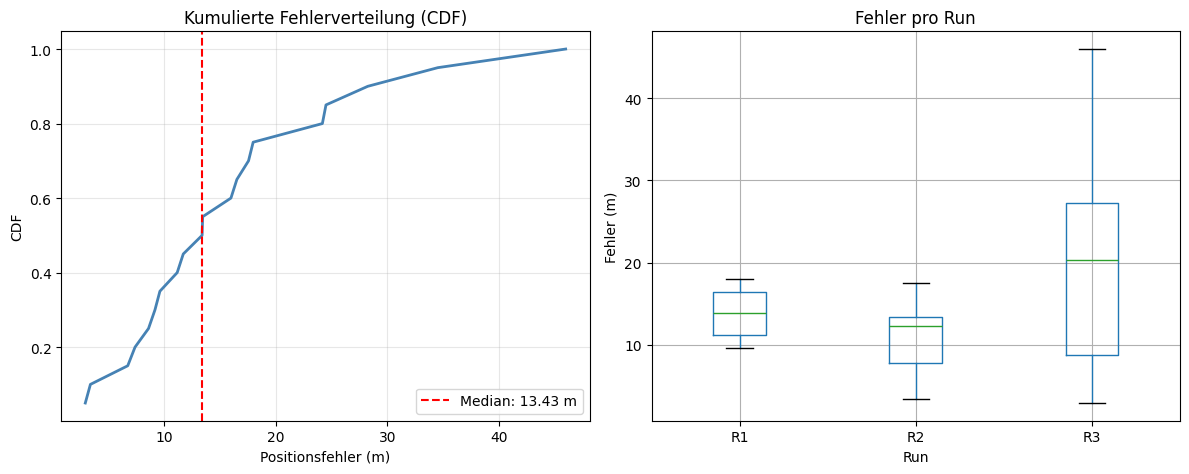

In [473]:
if error_dfs and len(all_errors) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sorted_err = np.sort(all_errors['error_m'])
    cdf = np.arange(1, len(sorted_err)+1) / len(sorted_err)
    axes[0].plot(sorted_err, cdf, color='steelblue', linewidth=2)
    axes[0].axvline(np.median(sorted_err), color='red', linestyle='--',
                    label=f'Median: {np.median(sorted_err):.2f} m')
    axes[0].set_xlabel('Positionsfehler (m)'); axes[0].set_ylabel('CDF')
    axes[0].set_title('Kumulierte Fehlerverteilung (CDF)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    all_errors.boxplot(column='error_m', by='run_id', ax=axes[1])
    axes[1].set_title('Fehler pro Run'); axes[1].set_xlabel('Run')
    axes[1].set_ylabel('Fehler (m)'); plt.suptitle('')
    plt.tight_layout()
    #plt.savefig('error_analysis.png', dpi=130)
    plt.show()
else:
    print('Fehler-Plot: Groundtruth-Daten erforderlich.')